# Trend Lens - Systematic Trading Strategy

## Overview
Trend Lens is a systematic, rule-based trading strategy developed entirely from 
first principles. It operates across 8 instruments simultaneously, using a 
multi-timeframe regime classification framework to filter trade entries on the 
15-minute timeframe.

The strategy was built through a structured five-stage research process, moving 
from hypothesis definition through historical validation, live automation, and 
into walk-forward testing before any results were considered meaningful.

This notebook presents the full performance analysis across an 18-month period 
from January 2025 to early July 2026, including portfolio metrics, per-instrument 
equity curves, trade distribution analysis, and an interactive trade viewer 
for inspecting individual signals on the chart.

## Instruments

| Category | Symbols |
|----------|---------|
| Crypto | BTCUSD, ETHUSD, BNBUSD |
| Forex Majors | EURUSD, GBPUSD, USDJPY, AUDUSD |
| Forex Cross | GBPJPY |

## Notes
- Returns are expressed in **R multiples** for cross-instrument comparability
- Dollar PnL figures use **0.1 lot** as a reference position size
- Strategy logic and parameters are intentionally omitted from this public document
- The strategy is currently in **walk-forward validation**

---
*Chinonso Anadumaka | Quantitative Trading Research | 2026*

In [63]:
# ============================================================
# IMPORTS & SETUP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import warnings
import os

warnings.filterwarnings("ignore")

# plot style 
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#0d1117",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#e6edf3",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "text.color": "#e6edf3",
    "grid.color": "#21262d",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family": "monospace",
    "figure.dpi": 120,
})

# color palette 
COLORS = {
    "green":    "#3fb950",
    "red":      "#f85149",
    "blue":     "#58a6ff",
    "orange":   "#d29922",
    "purple":   "#bc8cff",
    "teal":     "#39d353",
    "white":    "#e6edf3",
    "muted":    "#8b949e",
    "bg":       "#0d1117",
    "surface":  "#161b22",
    "border":   "#30363d",
}

# symbol colors for multi-line plots
SYMBOL_COLORS = {
    "BTCUSD": "#f7931a",   # bitcoin orange
    "ETHUSD": "#627eea",   # ethereum blue
    "BNBUSD": "#f3ba2f",   # binance yellow
    "EURUSD": "#3fb950",   # green
    "GBPUSD": "#58a6ff",   # blue
    "USDJPY": "#bc8cff",   # purple
    "AUDUSD": "#d29922",   # gold
    "GBPJPY": "#f85149",   # red
}


# symbols list
SYMBOLS = ["BTCUSD", "ETHUSD", "BNBUSD", "EURUSD", "GBPUSD", "USDJPY", "AUDUSD", "GBPJPY"]

# data folder
DATA_FOLDER = "data"

print("Setup complete")
print(f"Symbols: {', '.join(SYMBOLS)}")

Setup complete
Symbols: BTCUSD, ETHUSD, BNBUSD, EURUSD, GBPUSD, USDJPY, AUDUSD, GBPJPY


## i.  Data

Each instrument has a dedicated trade file containing every signal generated by the strategy from January 2025 to July 2026. Trades were identified through a systematic backtesting pipeline applied uniformly across all 8 instruments using identical parameters.

### Trade File Structure

| Column | Description |
|--------|-------------|
| `entry_time` | Timestamp of the trade entry |
| `year` | Year of the trade — used for annual breakdowns |
| `direction` | Trade direction: `long` or `short` |
| `open` / `high` / `low` / `close` | OHLC of the entry candle on the 15-minute timeframe |
| `entry_price` | Price at which the trade was entered |
| `stop` | Stop loss level — candle low (long) or candle high (short) |
| `target` | Take profit level — 1.5× the risk distance from entry |
| `success` | Outcome: `1` = target hit, `0` = stop hit |
| `pnl_r` | Trade result in R multiples: `+1.5` (win) or `-1.0` (loss) |
| `cumulative_r` | Running total of R across all trades in sequence |
| `pnl_usd` | Dollar PnL at 0.1 lot reference size |
| `cumulative_pnl` | Running total dollar PnL |

### Risk-Reward Structure

Every trade uses a fixed **1.5R** risk-reward ratio:
- **Risk**: distance from entry price to stop loss (1R)
- **Reward**: 1.5× the risk distance (1.5R)
- **Win**: +1.5R | **Loss**: −1.0R

This means the strategy needs a win rate above **40%** to be profitable — providing a meaningful buffer above breakeven.

In [5]:
# ============================================================
# LOAD TRADE DATA
# ============================================================

# load each symbol's trade file into a dictionary
# keyed by symbol name for easy access throughout the notebook

trades = {}

for symbol in SYMBOLS:
    filepath = os.path.join(DATA_FOLDER, f"{symbol}_trades.xlsx")
    df = pd.read_excel(filepath, sheet_name="trades", index_col="entry_time", parse_dates=True)
    trades[symbol] = df
    print(f"[{symbol}] {len(df)} trades | {df.index[0].date()} → {df.index[-1].date()}")

print(f"\nTotal trades loaded: {sum(len(df) for df in trades.values())}")

[BTCUSD] 170 trades | 2025-01-01 → 2026-07-02
[ETHUSD] 143 trades | 2025-01-03 → 2026-07-01
[BNBUSD] 207 trades | 2025-01-09 → 2026-07-02
[EURUSD] 117 trades | 2025-01-07 → 2026-06-22
[GBPUSD] 123 trades | 2025-01-10 → 2026-06-25
[USDJPY] 111 trades | 2025-01-06 → 2026-06-26
[AUDUSD] 146 trades | 2025-01-03 → 2026-07-01
[GBPJPY] 145 trades | 2025-01-14 → 2026-06-25

Total trades loaded: 1162


In [100]:
# eurusd_shorts = trades["EURUSD"][trades["EURUSD"]["direction"] == "short"]
# print(f"EURUSD short trades: {len(eurusd_shorts)}")
# print(f"EURUSD short wins: {(eurusd_shorts['success'] == 1).sum()}")

In [7]:
# ============================================================
# DATA PREVIEW
# ============================================================

# select a sample of trades from BTCUSD to illustrate the data structure
# only show the columns relevant to understanding a single trade
sample = trades["BTCUSD"].head(5)[[
    "year", "direction", "entry_price", "stop", "target",
    "success", "pnl_r", "cumulative_r", "pnl_usd", "cumulative_pnl"
]]

# format numbers cleanly and color-code wins/losses
# green for positive pnl, red for negative
styled = sample.style\
    .format({
        "entry_price":    "{:.2f}",       # price to 2 decimal places
        "stop":           "{:.2f}",
        "target":         "{:.2f}",
        "pnl_r":          "{:+.1f}",      # show sign explicitly (+1.5 or -1.0)
        "cumulative_r":   "{:.1f}",
        "pnl_usd":        "${:+.2f}",     # dollar sign with sign
        "cumulative_pnl": "${:.2f}",
    })\
    .map(
        # color positive values green, negative values red
        lambda v: "color: #3fb950" if isinstance(v, (int, float)) and v > 0
                  else "color: #f85149" if isinstance(v, (int, float)) and v < 0
                  else "",
        subset=["pnl_r", "pnl_usd"]      # only color the pnl columns
    )\
    .set_properties(**{
        "background-color": "#161b22",    # dark surface matching notebook theme
        "color":            "#e6edf3",    # light text
        "border-color":     "#30363d",    # subtle border
        "font-family":      "monospace",  # monospace for alignment
        "font-size":        "12px",
    })\
    .set_caption("Sample — BTCUSD Trades (first 5 rows)")

display(styled)

,year,direction,entry_price,stop,target,success,pnl_r,cumulative_r,pnl_usd,cumulative_pnl
entry_time,,,,,,,,,,
2025-01-01 14:15:00,2025,long,93597.58,93155.35,94260.92,1,+1.5,1.5,$+66.33,$66.33
2025-01-05 10:00:00,2025,short,97922.12,98240.19,97445.01,1,+1.5,3.0,$+47.71,$114.04
2025-01-10 19:45:00,2025,long,95805.46,94245.37,98145.60,0,-1.0,2.0,$-156.01,$-41.97
2025-01-11 22:45:00,2025,long,94530.57,94379.48,94757.21,1,+1.5,3.5,$+22.66,$-19.31
2025-01-12 21:45:00,2025,short,94608.88,94786.83,94341.96,1,+1.5,5.0,$+26.69,$7.38


## ii. Portfolio Performance Summary

The table below summarises the key performance metrics for each instrument across the full research period. Metrics are calculated from the trade-level data and expressed in R multiples to allow fair cross-instrument comparison.

### Metric Definitions

| Metric | Description |
|--------|-------------|
| **Trades** | Total number of signals generated and evaluated |
| **Win Rate** | Percentage of trades that hit the target |
| **Expectancy** | Average R earned per trade — the core profitability measure |
| **Total R** | Cumulative R across all trades |
| **Sharpe Ratio** | Risk-adjusted return — mean R divided by standard deviation of R, annualised |
| **Sortino Ratio** | Like Sharpe but only penalises downside volatility |
| **Max Drawdown** | Largest peak-to-trough decline in cumulative R |
| **Total PnL** | Dollar return at 0.1 lot reference size |

A **Sharpe ratio above 1.0** is generally considered acceptable. Above 2.0 is strong for a systematic strategy.

In [50]:
# ============================================================
# PERFORMANCE METRICS CALCULATION
# ============================================================
def calculate_metrics(df, symbol):
    """
    Calculate key performance metrics from a trade dataframe.
    R metrics are expressed in R multiples.
    Sharpe is calculated on dollar PnL and annualised by trade frequency.
    """
    # --- basic counts ---
    total_trades = len(df)
    wins = (df["success"] == 1).sum()
    losses = (df["success"] == 0).sum()
    win_rate = wins / total_trades if total_trades > 0 else 0

    # --- directional win rates ---
    longs = df[df["direction"] == "long"]
    shorts = df[df["direction"] == "short"]
    long_wr = (longs["success"] == 1).sum() / len(longs) if len(longs) > 0 else 0
    short_wr = (shorts["success"] == 1).sum() / len(shorts) if len(shorts) > 0 else 0

    # --- R-based metrics ---
    pnl = df["pnl_r"].dropna()
    total_r = pnl.sum()
    expectancy = pnl.mean()

    # --- annualisation factor ---
    # based on actual trade frequency rather than calendar days
    # avoids inflating sharpe for strategies that don't trade every day
    days_covered = (df.index[-1] - df.index[0]).days
    trades_per_year = total_trades / (days_covered / 365) if days_covered > 0 else 1
    annual_factor = np.sqrt(trades_per_year)

    # --- sharpe ratio on dollar PnL ---
    # dollar PnL has variable returns unlike binary R outcomes
    # produces a more meaningful and defensible sharpe calculation
    pnl_usd = df["pnl_usd"].dropna()
    mean_usd = pnl_usd.mean()
    std_usd = pnl_usd.std()
    sharpe = (mean_usd / std_usd) * annual_factor if std_usd > 0 else 0

    # --- max drawdown in R ---
    # largest peak-to-trough decline in cumulative R
    cumulative = df["cumulative_r"].dropna()
    rolling_max = cumulative.cummax()
    drawdown = cumulative - rolling_max
    max_drawdown = drawdown.min()

    # --- profit factor ---
    # gross wins divided by gross losses
    gross_wins = pnl[pnl > 0].sum()
    gross_losses = abs(pnl[pnl < 0].sum())
    profit_factor = gross_wins / gross_losses if gross_losses > 0 else 0

    # --- dollar pnl ---
    total_pnl_usd = df["cumulative_pnl"].iloc[-1] if "cumulative_pnl" in df.columns else 0

    return {
        "Symbol": symbol,
        "Trades": total_trades,
        "Win Rate": f"{win_rate:.1%}",
        "Long WR": f"{long_wr:.1%}",
        "Short WR": f"{short_wr:.1%}",
        "Expectancy (R)": f"{expectancy:+.3f}",
        "Total R": f"{total_r:.1f}R",
        "Sharpe": f"{sharpe:.2f}",
        "Profit Factor": f"{profit_factor:.2f}",
        "Max DD (R)": f"{max_drawdown:.1f}R",
        "Total PnL": f"${total_pnl_usd:,.2f}",
    }

# --- calculate metrics for all symbols ---
metrics_list = [calculate_metrics(trades[symbol], symbol) for symbol in SYMBOLS]
metrics_df = pd.DataFrame(metrics_list).set_index("Symbol")
print("Metrics calculated for all symbols")
print(metrics_df)

Metrics calculated for all symbols
        Trades Win Rate Long WR Short WR Expectancy (R) Total R Sharpe  \
Symbol                                                                   
BTCUSD     170    68.2%   69.2%    66.7%         +0.706  120.0R   3.88   
ETHUSD     143    69.2%   65.2%    75.9%         +0.731  104.5R   4.45   
BNBUSD     207    65.2%   63.9%    67.0%         +0.630  130.5R   4.92   
EURUSD     117    70.1%   63.7%    83.8%         +0.752   88.0R   3.66   
GBPUSD     123    65.9%   61.7%    73.8%         +0.646   79.5R   2.82   
USDJPY     111    69.4%   67.6%    73.0%         +0.750   82.5R   4.01   
AUDUSD     146    61.6%   61.8%    61.4%         +0.552   80.0R   3.41   
GBPJPY     145    62.8%   62.0%    64.4%         +0.569   82.5R   2.75   

       Profit Factor Max DD (R)  Total PnL  
Symbol                                      
BTCUSD          3.22      -4.0R  $4,048.70  
ETHUSD          3.38      -4.0R    $145.61  
BNBUSD          2.81      -4.0R     $42.11  

> ## Note on Dollar PnL
> The Total PnL column uses 0.1 lot as a uniform reference size across all 
> instruments. However, pip/point values vary significantly between instruments — 
> BTC moves in large dollar increments per pip, while ETH and BNB generate much 
> smaller dollar moves at the same lot size, and would require a higher lot size 
> to match BTC's dollar output at equivalent risk.
>
> For cross-instrument comparison, **R multiples are the correct metric.** 
> They normalize returns relative to risk taken on each trade, making performance 
> comparable regardless of instrument pip value.

In [51]:
# ============================================================
# PORTFOLIO PERFORMANCE SUMMARY TABLE
# ============================================================

# create a styled version of the metrics table for clean display
# color code key metrics to make performance differences immediately visible

def style_metrics_table(df):
    """
    Apply conditional formatting to the metrics dataframe.
    Green = strong performance, red = weak, with gradient in between.
    """

    styled = df.style

    # --- color win rate column ---
    # above 65% = green, below 55% = red, in between = neutral
    def color_winrate(val):
        pct = float(val.strip("%")) / 100
        if pct >= 0.65:
            return "color: #3fb950; font-weight: bold"
        elif pct < 0.55:
            return "color: #f85149"
        return "color: #d29922"

    # --- color expectancy column ---
    # positive = green, negative = red
    def color_expectancy(val):
        num = float(val.replace("+", ""))
        if num >= 0.65:
            return "color: #3fb950; font-weight: bold"
        elif num >= 0.5:
            return "color: #d29922"
        return "color: #f85149"

    # --- color sharpe column ---
    # above 3.0 = green, above 2.0 = orange, below = red
    def color_sharpe(val):
        num = float(val)
        if num >= 3.0:
            return "color: #3fb950; font-weight: bold"
        elif num >= 2.0:
            return "color: #d29922"
        return "color: #f85149"

    # --- color profit factor ---
    # above 3.0 = green, above 2.0 = orange, below = red
    def color_pf(val):
        num = float(val)
        if num >= 3.0:
            return "color: #3fb950; font-weight: bold"
        elif num >= 2.0:
            return "color: #d29922"
        return "color: #f85149"

    # --- color max drawdown ---
    # smaller drawdown = better, so reverse the logic
    def color_dd(val):
        num = float(val.replace("R", ""))
        if num >= -3.5:
            return "color: #3fb950; font-weight: bold"
        elif num >= -4.5:
            return "color: #d29922"
        return "color: #f85149"

    # --- apply all colorings ---
    styled = styled\
        .map(color_winrate,    subset=["Win Rate", "Long WR", "Short WR"])\
        .map(color_expectancy, subset=["Expectancy (R)"])\
        .map(color_sharpe,     subset=["Sharpe"])\
        .map(color_pf,         subset=["Profit Factor"])\
        .map(color_dd,         subset=["Max DD (R)"])\
        .set_properties(**{
            "background-color": "#161b22",
            "color":            "#e6edf3",
            "border-color":     "#30363d",
            "font-family":      "monospace",
            "font-size":        "12px",
            "padding":          "6px 12px",
        })\
        .set_table_styles([
            # header row styling
            {
                "selector": "th",
                "props": [
                    ("background-color", "#0d1117"),
                    ("color",            "#58a6ff"),
                    ("font-family",      "monospace"),
                    ("font-size",        "12px"),
                    ("padding",          "6px 12px"),
                    ("border-bottom",    "1px solid #30363d"),
                ]
            },
            # index column styling
            {
                "selector": "th.row_heading",
                "props": [
                    ("color",       "#f7931a"),
                    ("font-weight", "bold"),
                ]
            },
            # caption styling
            {
                "selector": "caption",
                "props": [
                    ("color",       "#8b949e"),
                    ("font-size",   "13px"),
                    ("padding",     "8px 0"),
                ]
            },
        ])\
        .set_caption("Portfolio Performance Summary — January 2025 to July 2026 | 0.1 Lot Reference Size")

    return styled


# --- display the styled table ---
styled_metrics = style_metrics_table(metrics_df)
display(styled_metrics)

,Trades,Win Rate,Long WR,Short WR,Expectancy (R),Total R,Sharpe,Profit Factor,Max DD (R),Total PnL
Symbol,,,,,,,,,,
BTCUSD,170,68.2%,69.2%,66.7%,+0.706,120.0R,3.88,3.22,-4.0R,"$4,048.70"
ETHUSD,143,69.2%,65.2%,75.9%,+0.731,104.5R,4.45,3.38,-4.0R,$145.61
BNBUSD,207,65.2%,63.9%,67.0%,+0.630,130.5R,4.92,2.81,-4.0R,$42.11
EURUSD,117,70.1%,63.7%,83.8%,+0.752,88.0R,3.66,3.51,-4.0R,"$1,061.70"
GBPUSD,123,65.9%,61.7%,73.8%,+0.646,79.5R,2.82,2.89,-3.0R,$990.55
USDJPY,111,69.4%,67.6%,73.0%,+0.750,82.5R,4.01,3.50,-3.0R,$694.17
AUDUSD,146,61.6%,61.8%,61.4%,+0.552,80.0R,3.41,2.45,-4.5R,$626.75
GBPJPY,145,62.8%,62.0%,64.4%,+0.569,82.5R,2.75,2.53,-4.5R,$994.96


> ## Note on Sharpe Ratio
> Sharpe is calculated on per-trade dollar PnL rather than R multiples.
> Because all R outcomes are binary (+1.5R or -1.0R), using R would produce
> artificially low variance and inflate the Sharpe. Dollar PnL varies across
> trades due to differences in price levels and pip values, producing a more
> meaningful and comparable figure. All values are annualised by actual trade
> frequency rather than calendar days.

## iii. Equity Curves

The equity curves below show the cumulative R earned over time for each instrument. Each point on the curve represents the running total R after each trade.

Key things to look for:

- **Upward slope** — the strategy is generating positive expectancy consistently over time
- **Drawdown depth** — how far the curve dips below its peak before recovering
- **Recovery speed** — how quickly the strategy returns to new highs after a losing streak
- **Consistency** — a smooth upward curve indicates stable performance across market conditions

All curves start at 0R and are plotted on the same scale where possible to allow fair visual comparison across instruments.

The final chart shows the **combined portfolio equity curve** — the sum of all 8 instruments traded simultaneously. Portfolio diversification reduces drawdowns and smooths the equity curve compared to any individual instrument.

In [64]:
# ============================================================
# EQUITY CURVE HELPER FUNCTION
# ============================================================
def plot_single_equity_curve(symbol, ax=None):
    """
    Plot the cumulative dollar PnL equity curve for a single symbol.
    Shades drawdown periods in red.
    """
    df = trades[symbol].copy()
    col = SYMBOL_COLORS[symbol]
    x = df.index
    y = df["cumulative_pnl"].values

    # calculate drawdown periods
    rolling_max = df["cumulative_pnl"].cummax()
    in_drawdown = df["cumulative_pnl"] < rolling_max

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 5))
        standalone = True
    else:
        standalone = False

    # shade drawdown periods
    ax.fill_between(
        x, y, rolling_max.values,
        where=in_drawdown,
        alpha=0.3, color=COLORS["red"],
        label="Drawdown"
    )

    # equity curve line
    ax.plot(x, y, color=col, linewidth=1.8, label=symbol)

    # zero reference line
    ax.axhline(0, color=COLORS["muted"], linewidth=0.5,
               linestyle="--", alpha=0.5)

    # build title — use USD prefix instead of dollar sign to avoid latex parsing
    win_rate = (df["success"] == 1).mean()
    total_pnl = df["cumulative_pnl"].iloc[-1]
    max_dd_pnl = (df["cumulative_pnl"] - df["cumulative_pnl"].cummax()).min()

    total_pnl_str = f"USD {total_pnl:,.0f}" if total_pnl >= 0 else f"USD -{abs(total_pnl):,.0f}"
    max_dd_str = f"USD -{abs(max_dd_pnl):,.0f}"

    ax.set_title(
        f"{symbol}  |  {total_pnl_str}  |  {win_rate:.1%} WR  |  Max DD: {max_dd_str}",
        color=col, fontsize=11, pad=8
    )

    # format x-axis as dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax.set_xlabel("Date", fontsize=8, color=COLORS["muted"])
    ax.set_ylabel("Cumulative PnL (USD)", fontsize=8, color=COLORS["muted"])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.savefig(f"plots/equity_{symbol}.png", dpi=150,
                    bbox_inches="tight", facecolor=COLORS["bg"])
        plt.show()

print("Equity curve helper ready")

Equity curve helper ready


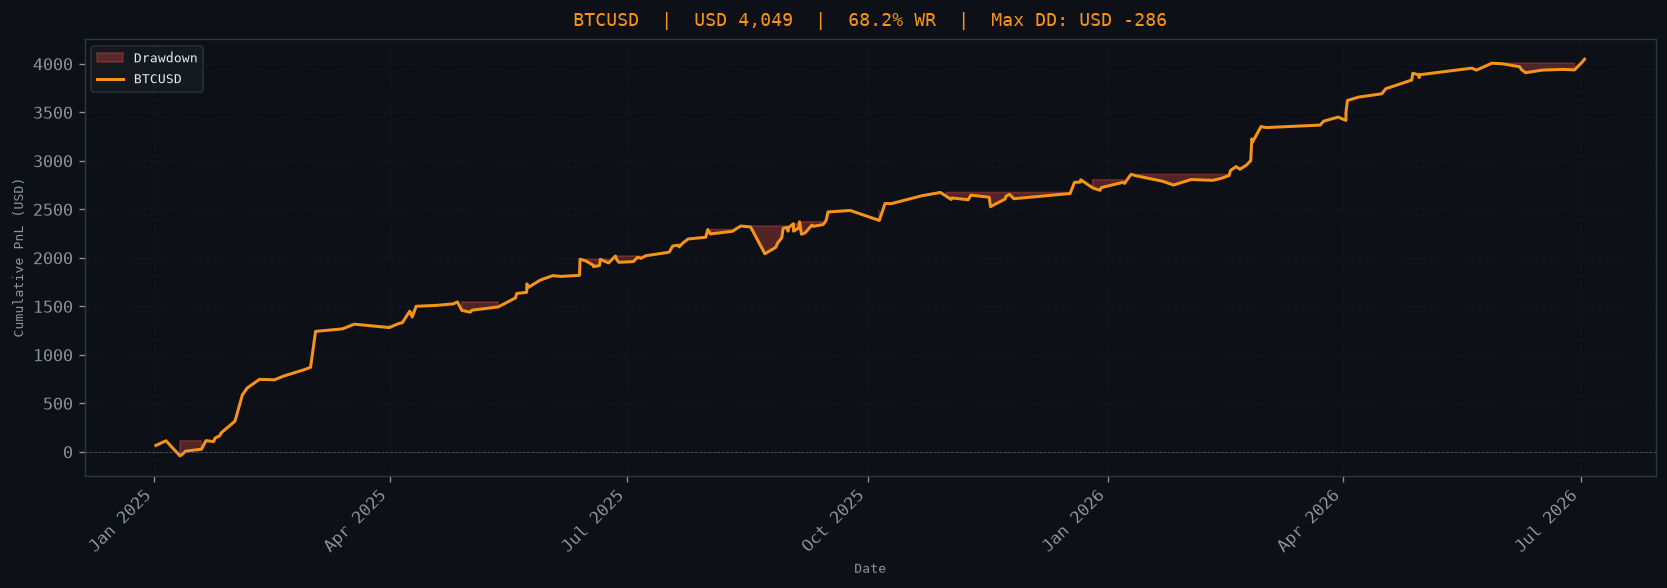

In [65]:
# BTCUSD
plot_single_equity_curve("BTCUSD")

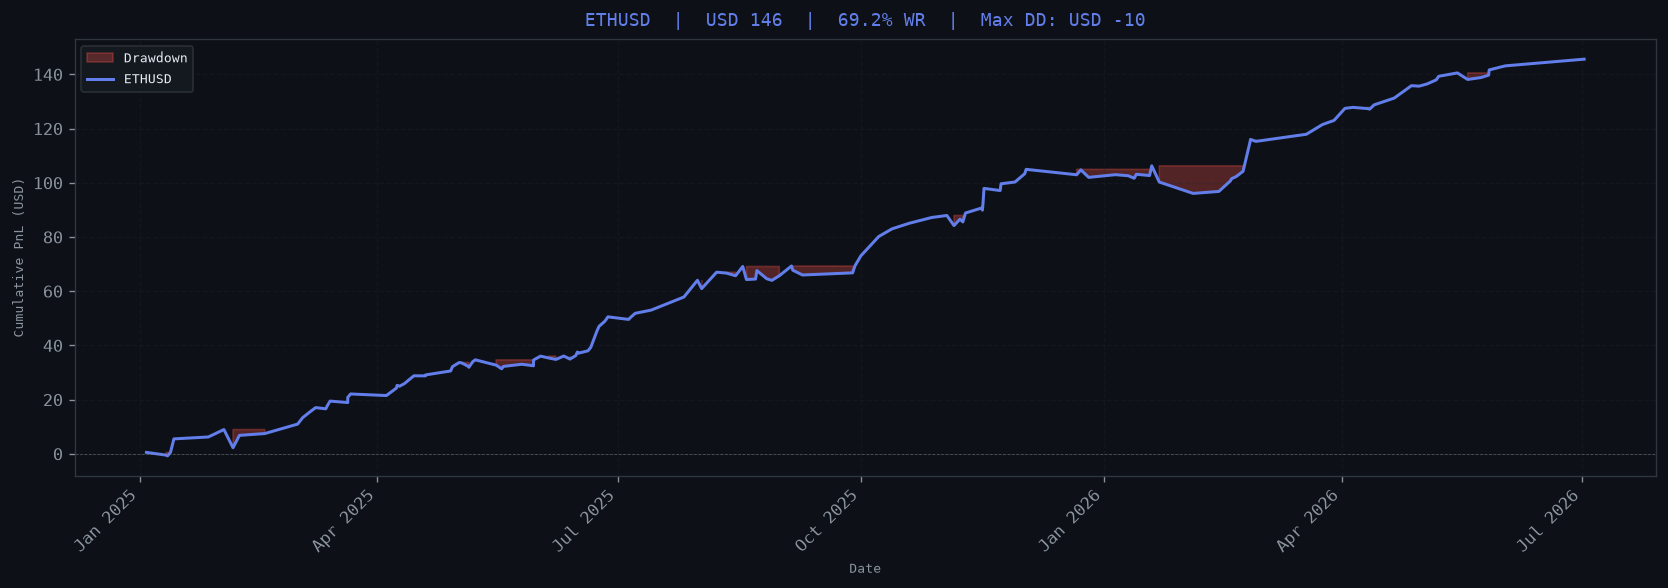

In [66]:
# ETHUSD
plot_single_equity_curve("ETHUSD")

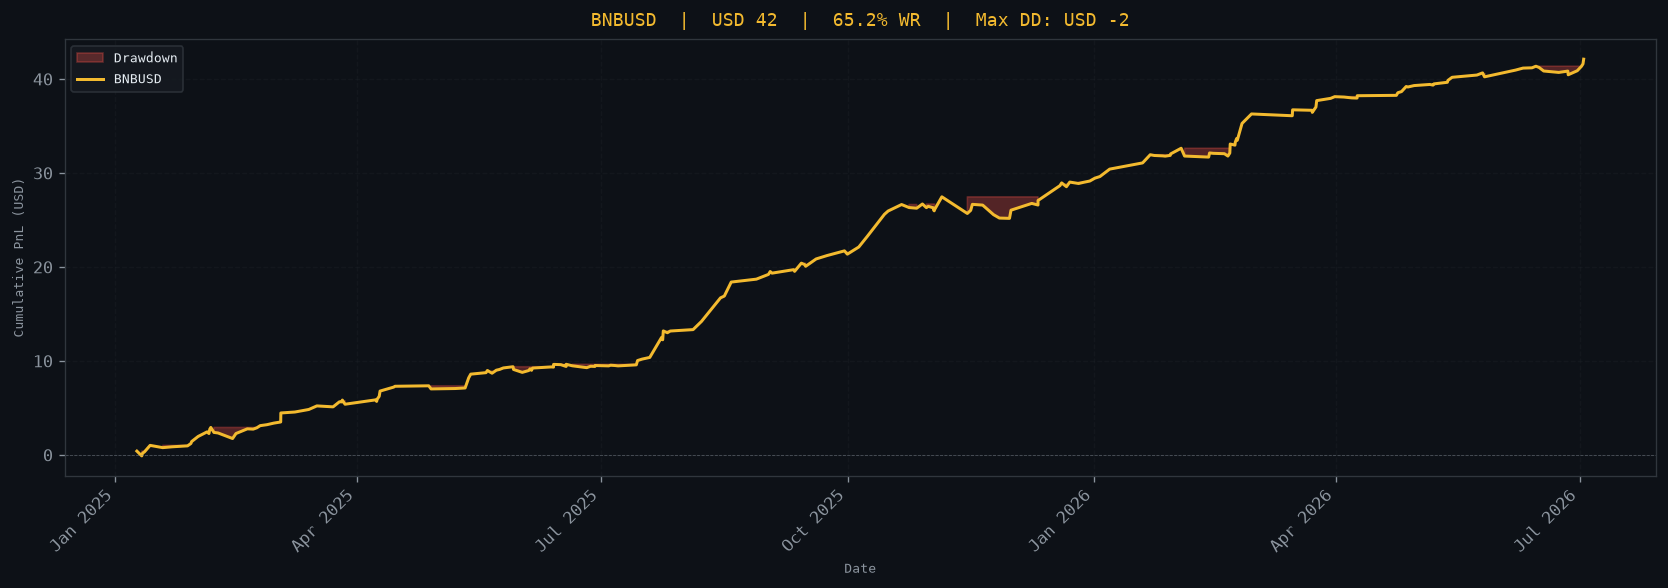

In [67]:
# BNBUSD
plot_single_equity_curve("BNBUSD")

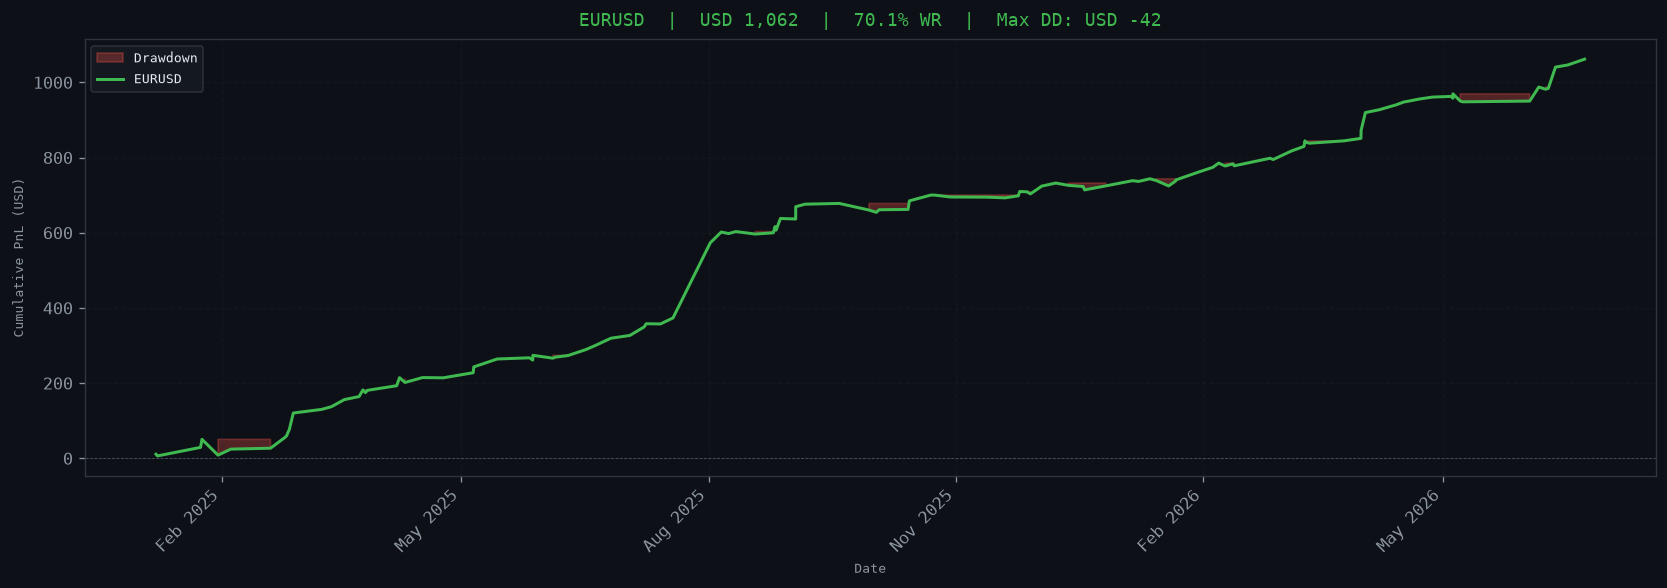

In [68]:
# EURUSD
plot_single_equity_curve("EURUSD")

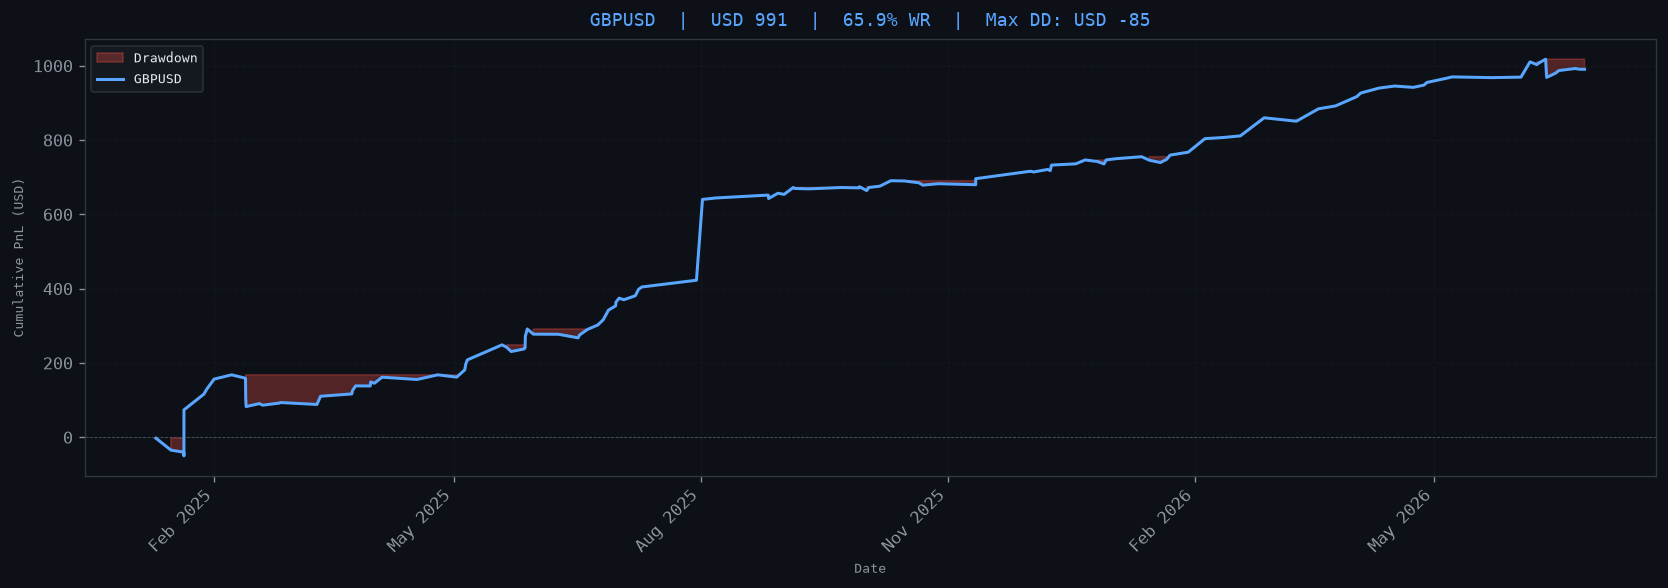

In [69]:
# GBPUSD
plot_single_equity_curve("GBPUSD")

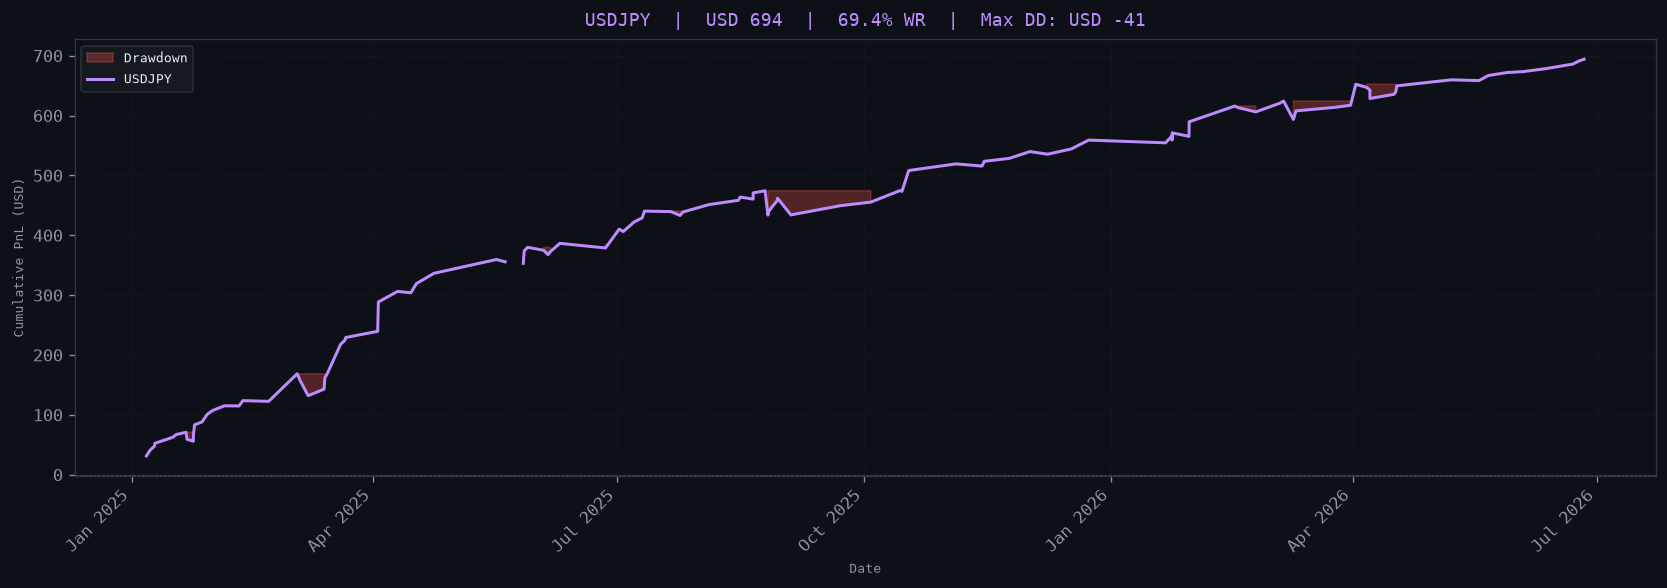

In [70]:
# USDJPY
plot_single_equity_curve("USDJPY")

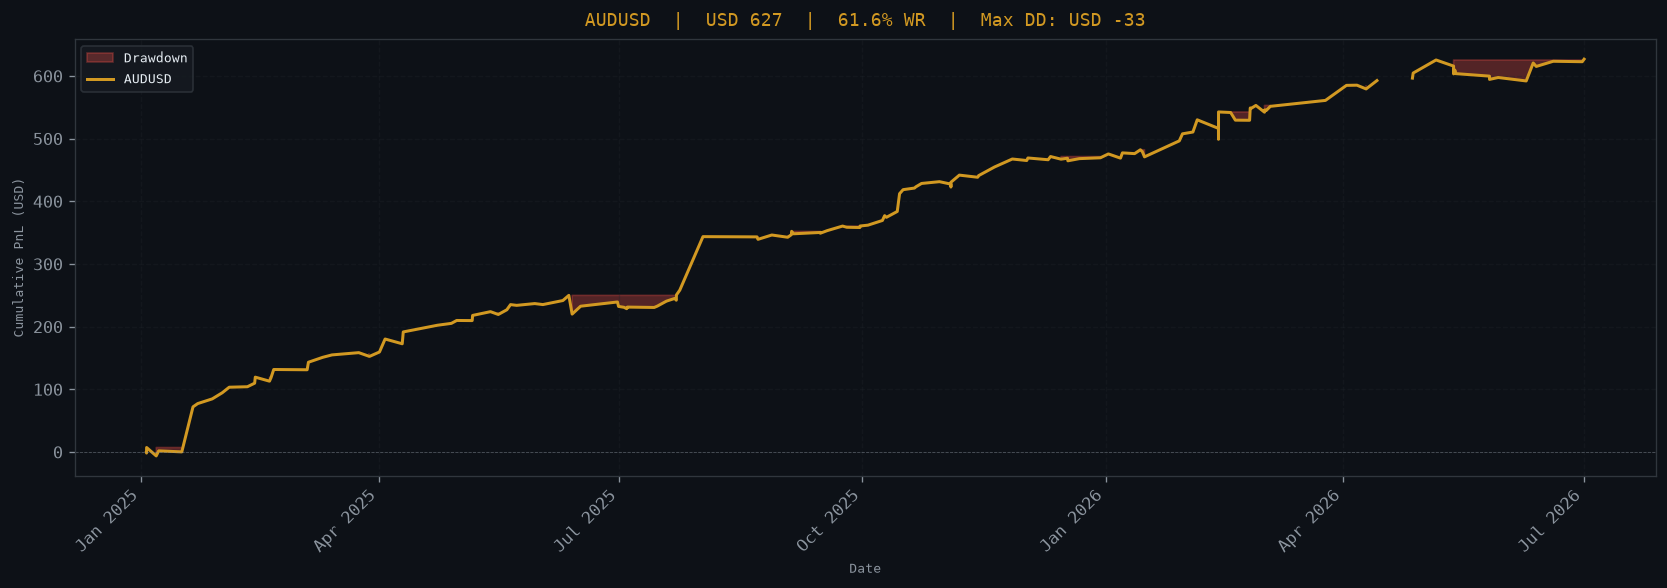

In [71]:
# AUDUSD
plot_single_equity_curve("AUDUSD")

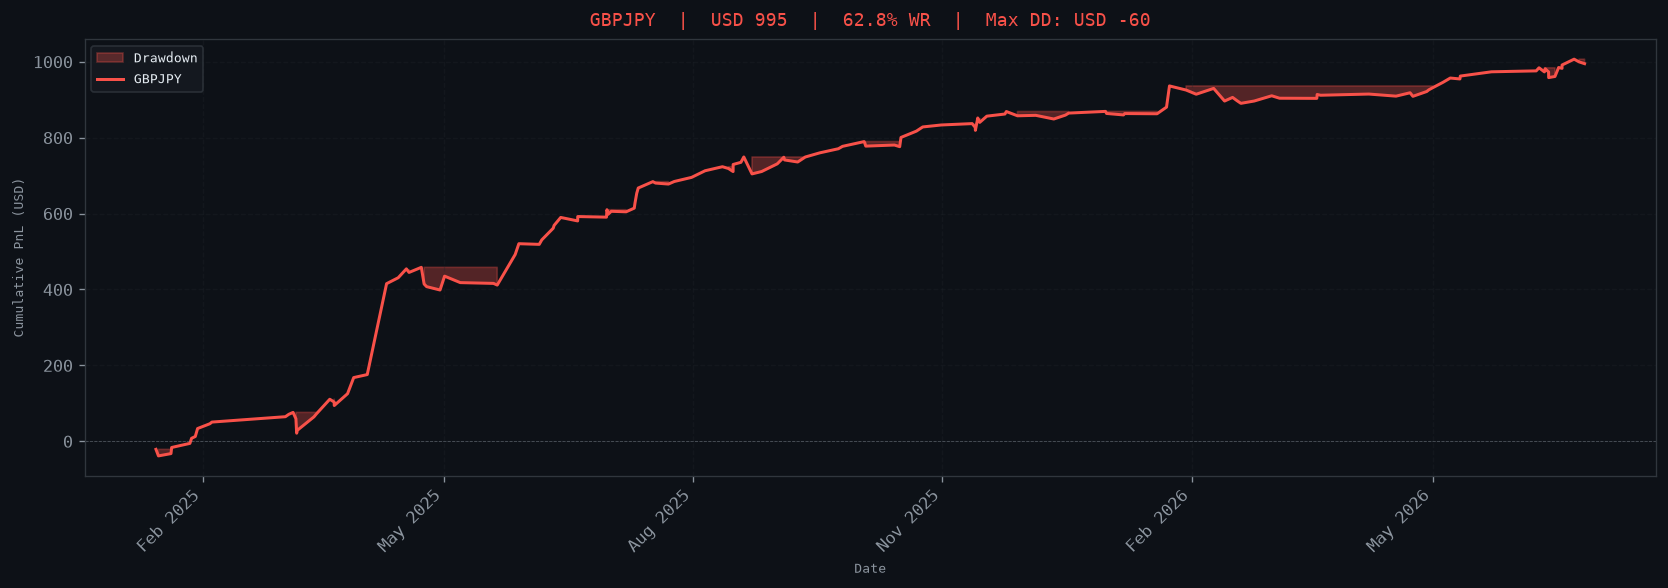

In [72]:
# GBPJPY
plot_single_equity_curve("GBPJPY")

> ### Note on early drawdowns
> GBPUSD and GBPJPY both dip below zero early in the period before recovering 
> and climbing consistently afterward. This reflects a difficult opening sequence 
> of trades rather than a fundamental weakness in the strategy. Both instruments 
> recover within weeks and go on to produce strong full-period results. A strategy 
> that never experiences early drawdowns is more likely to be curve-fitted than 
> one that does and recovers.

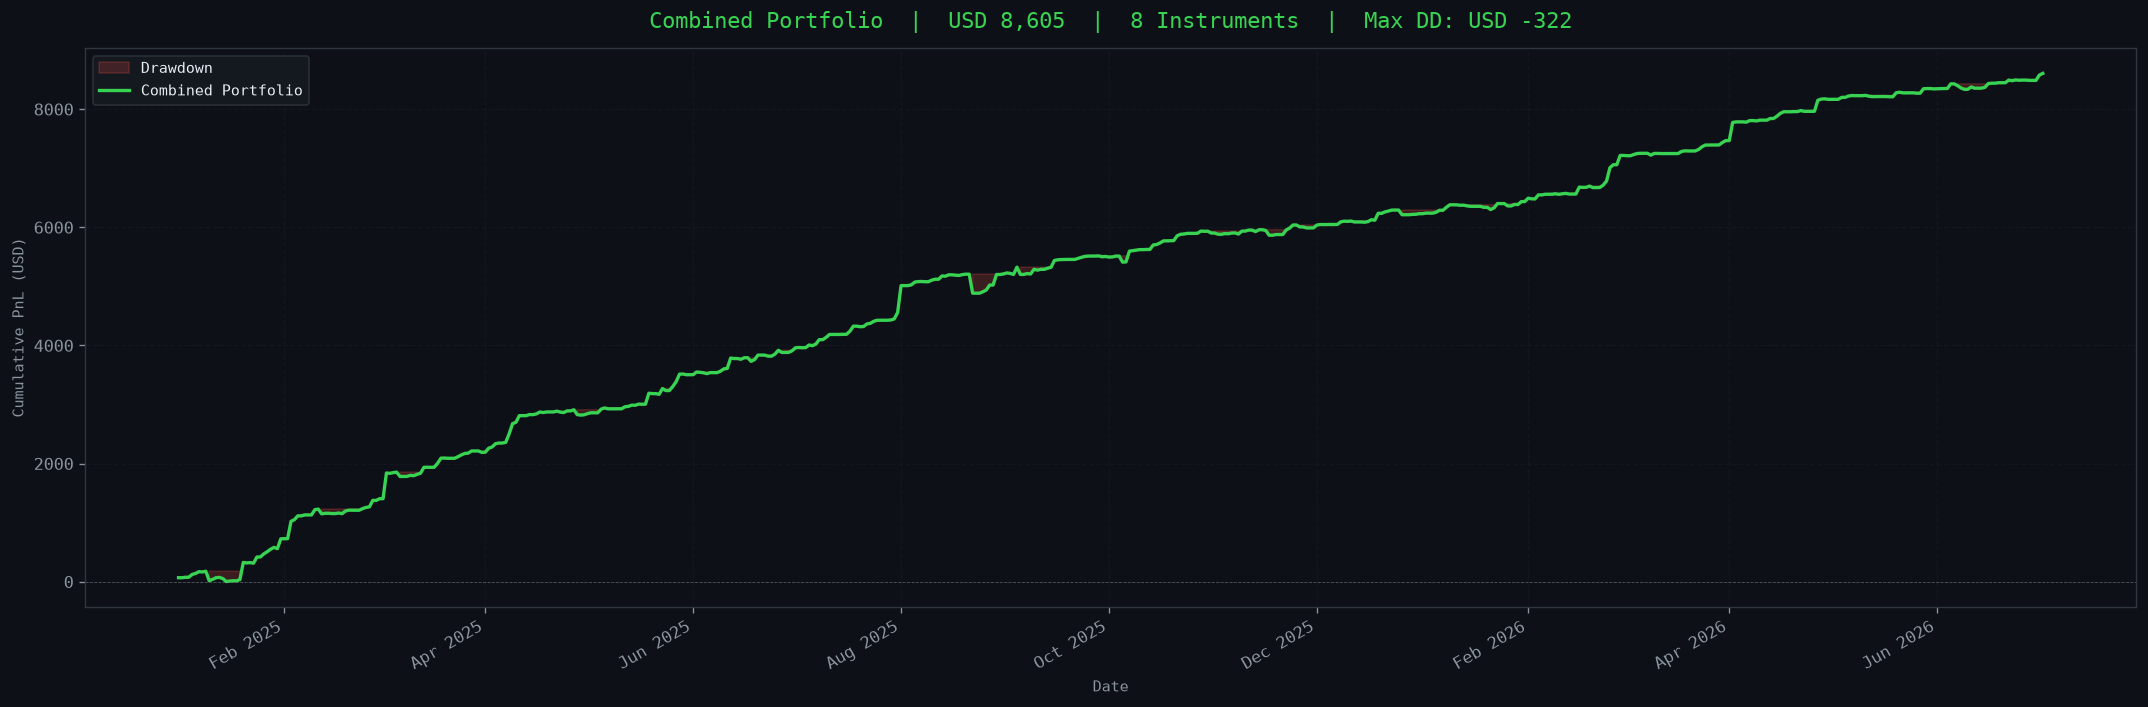

In [85]:
# ============================================================
# COMBINED PORTFOLIO EQUITY CURVE
# ============================================================
# build a daily dollar PnL series for each symbol then sum across all symbols
# this shows the aggregate performance of trading all 8 simultaneously
combined = pd.DataFrame()
for symbol in SYMBOLS:
    df = trades[symbol][["pnl_usd"]].copy()
    df.index = pd.to_datetime(df.index)
    # resample to daily — sum all PnL earned on the same day
    daily = df["pnl_usd"].resample("D").sum()
    combined[symbol] = daily

# fill days with no trades as 0
combined = combined.fillna(0)
portfolio_pnl = combined.sum(axis=1)
portfolio_cum = portfolio_pnl.cumsum()

# drawdown calculation
rolling_max_p = portfolio_cum.cummax()
in_drawdown_p = portfolio_cum < rolling_max_p
max_dd_p = (portfolio_cum - rolling_max_p).min()

fig, ax = plt.subplots(figsize=(18, 6))

# shade drawdown periods
ax.fill_between(
    portfolio_cum.index,
    portfolio_cum.values,
    rolling_max_p.values,
    where=in_drawdown_p,
    alpha=0.2, color=COLORS["red"],
    label="Drawdown"
)

# portfolio equity curve
ax.plot(
    portfolio_cum.index, portfolio_cum.values,
    color=COLORS["teal"], linewidth=2.0,
    label="Combined Portfolio"
)

ax.axhline(0, color=COLORS["muted"], linewidth=0.5,
           linestyle="--", alpha=0.5)

# format x axis as dates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# build title strings to avoid matplotlib dollar sign parsing
total_pnl_str = f"USD {portfolio_cum.iloc[-1]:,.0f}"
max_dd_str = f"USD -{abs(max_dd_p):,.0f}"

ax.set_title(
    f"Combined Portfolio  |  {total_pnl_str}  |  8 Instruments  |  Max DD: {max_dd_str}",
    color=COLORS["teal"], fontsize=13, pad=12
)

ax.set_xlabel("Date", fontsize=9, color=COLORS["muted"])
ax.set_ylabel("Cumulative PnL (USD)", fontsize=9, color=COLORS["muted"])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/equity_portfolio.png", dpi=150,
            bbox_inches="tight", facecolor=COLORS["bg"])
plt.show()

## Combined Portfolio Equity Curve

The chart above aggregates performance across all 8 instruments traded simultaneously.
Portfolio diversification smooths individual instrument volatility — losing streaks on
one instrument are offset by continued performance on others.

**Portfolio max drawdown: USD -322 on USD 8,605 total gain — a 3.7% peak drawdown ratio.**

## iv. Trade Distribution Analysis

The charts below examine how trades are distributed across time and direction. This section addresses a key concern in systematic strategy evaluation — **consistency**.

A strategy that performs well overall but clusters its wins in a short period, or performs very differently across different market conditions, is less reliable than one that generates consistent results throughout.

### What to look for

- **Monthly trade frequency** — are signals distributed evenly across the year or clustered in specific months?
- **Win/Loss distribution** — does the win rate hold up across the full period or does it degrade over time?
- **Long vs Short balance** — does the strategy perform consistently in both directions?
- **Annual breakdown** — how does performance compare year over year?

### Monthly Trade Frequency

The heatmap below shows how many trades were generated per instrument per month.
A well-distributed strategy should show activity across all months rather than 
clustering in specific periods.

Across all 8 instruments and 18 months, no single month dominates signal generation 
— confirming the strategy responds to market conditions rather than calendar effects.

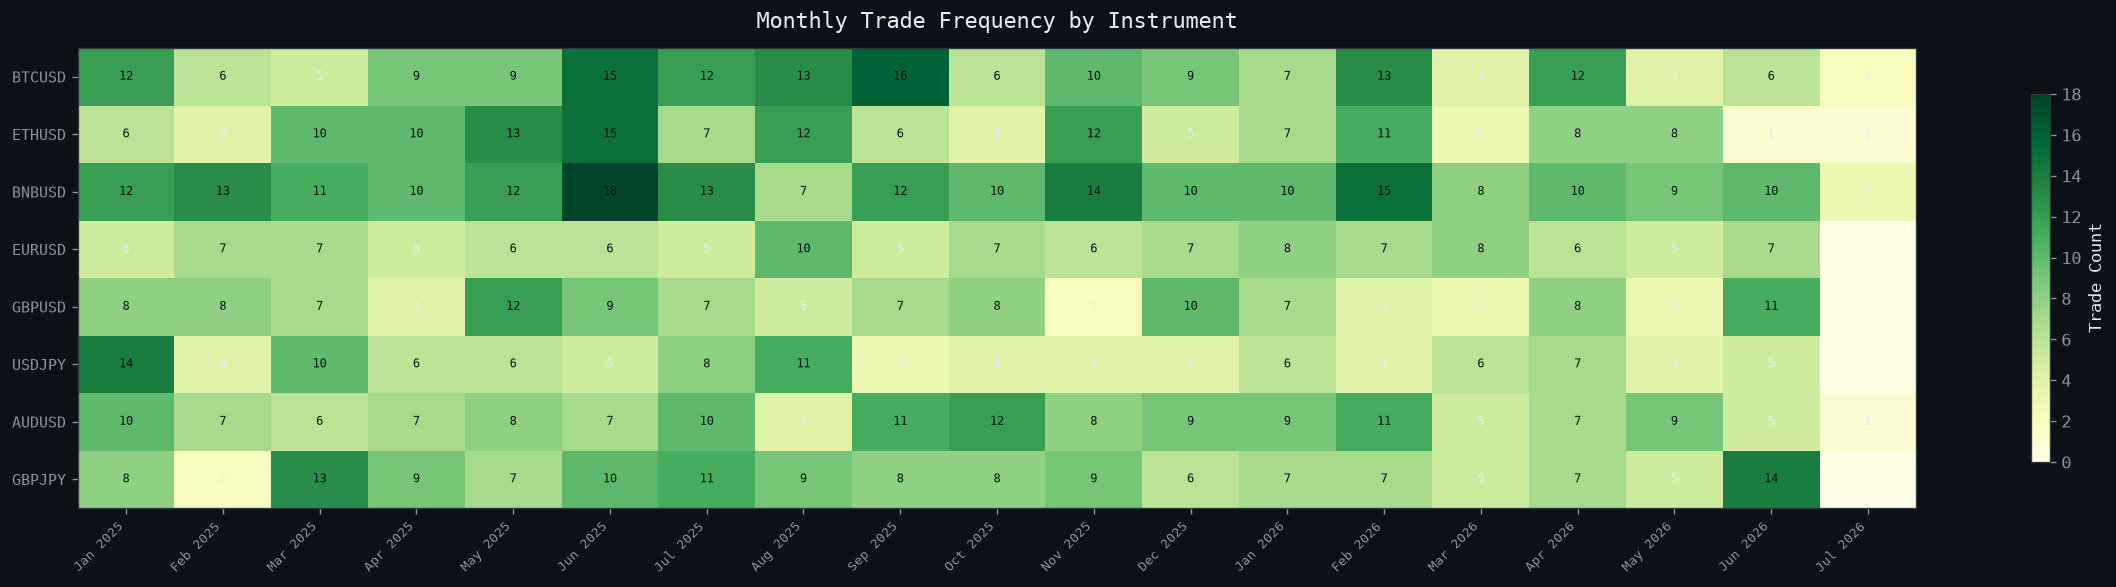

In [86]:
# ============================================================
# MONTHLY TRADE FREQUENCY HEATMAP
# ============================================================

# count trades per symbol per month
monthly_counts = pd.DataFrame()
for symbol in SYMBOLS:
    df = trades[symbol].copy()
    df.index = pd.to_datetime(df.index)
    # resample to month end and count trades
    monthly = df.resample("ME").size()
    monthly_counts[symbol] = monthly

monthly_counts = monthly_counts.fillna(0)
monthly_counts.index = monthly_counts.index.strftime("%b %Y")

# transpose — symbols as rows, months as columns
heatmap_data = monthly_counts.T

fig, ax = plt.subplots(figsize=(20, 5))

im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="YlGn",
    vmin=0,
    vmax=heatmap_data.values.max()
)

# x axis — month labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right", fontsize=8)

# y axis — symbol labels
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)

# add trade count inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = int(heatmap_data.values[i, j])
        if val > 0:
            ax.text(
                j, i, str(val),
                ha="center", va="center",
                fontsize=7,
                color="#0d1117" if val > 5 else "#e6edf3"
            )

plt.colorbar(im, ax=ax, shrink=0.8, label="Trade Count")
ax.set_title(
    "Monthly Trade Frequency by Instrument",
    color=COLORS["white"], fontsize=13, pad=12
)

plt.tight_layout()
plt.savefig("plots/monthly_frequency.png", dpi=150, bbox_inches="tight",
            facecolor=COLORS["bg"])
plt.show()

### Rolling Win Rate

The chart below shows the rolling 30-trade win rate across all instruments combined.
This reveals whether the strategy's edge is consistent over time or whether 
performance degrades in certain periods.

The red dashed line marks the 40% breakeven threshold — the minimum win rate 
needed to be profitable at 1.5R. The rolling win rate remains above this threshold 
throughout the majority of the test period, with brief dips that recover quickly 
rather than representing sustained degradation.

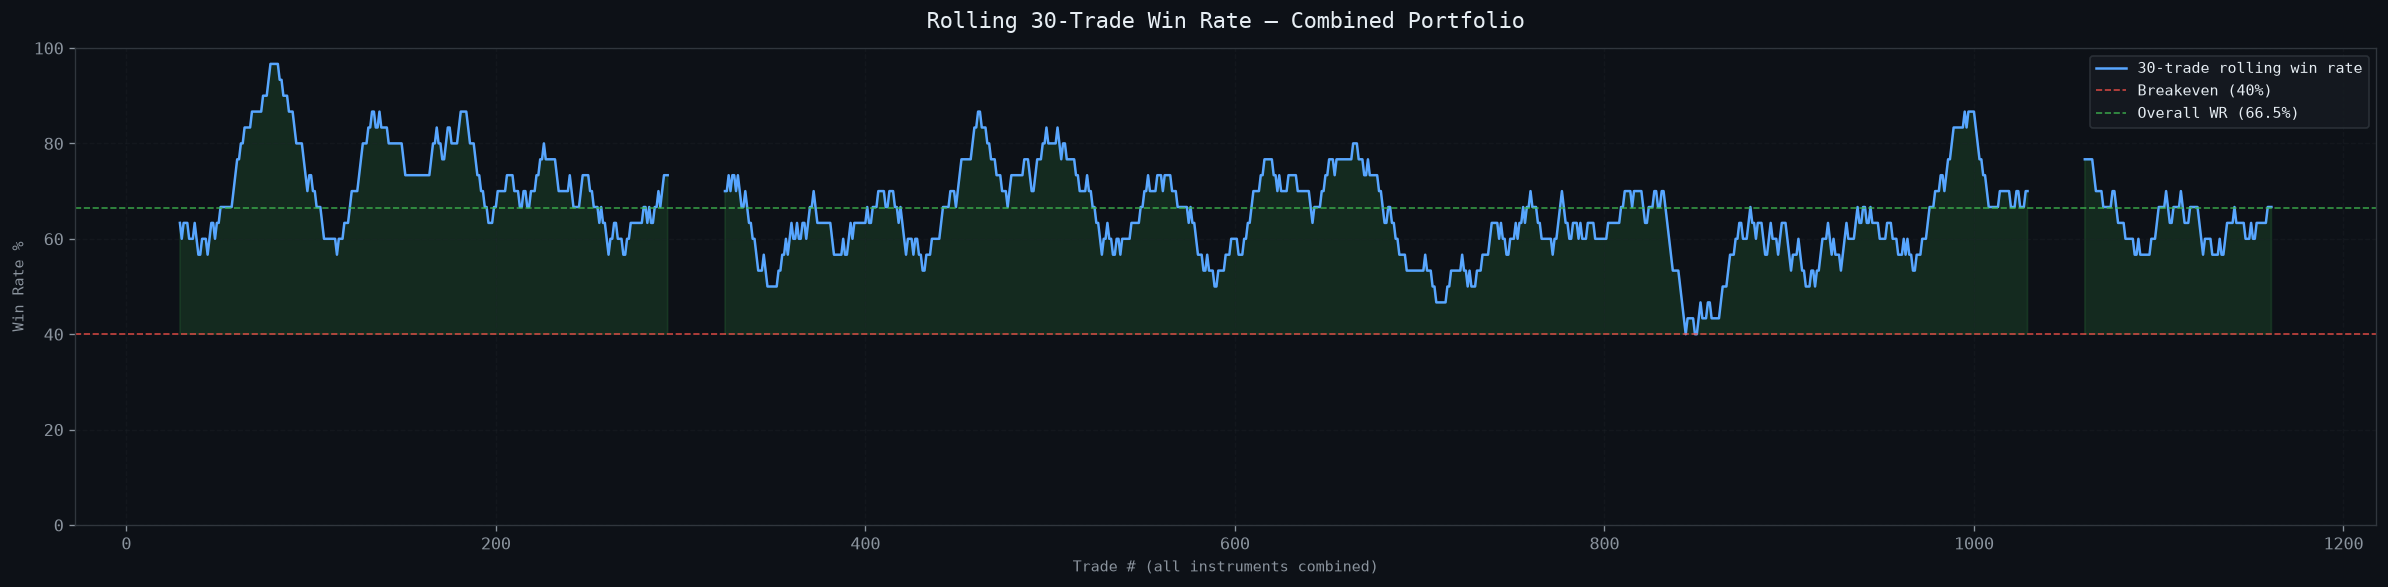

In [87]:
# ============================================================
# ROLLING WIN RATE — COMBINED PORTFOLIO
# ============================================================

# combine all trades into one chronologically sorted series
all_trades = pd.concat([
    trades[symbol][["success", "direction"]].assign(symbol=symbol)
    for symbol in SYMBOLS
]).sort_index()

# rolling 30-trade win rate across all instruments
window     = 30
rolling_wr = all_trades["success"].rolling(window).mean() * 100
overall_wr = all_trades["success"].mean() * 100

fig, ax = plt.subplots(figsize=(20, 5))

# plot rolling win rate line
ax.plot(
    range(len(rolling_wr)),
    rolling_wr.values,
    color=COLORS["blue"],
    linewidth=1.5,
    label=f"{window}-trade rolling win rate"
)

# breakeven reference line at 40%
ax.axhline(
    40, color=COLORS["red"], linewidth=1.0,
    linestyle="--", alpha=0.8, label="Breakeven (40%)"
)

# overall win rate reference line
ax.axhline(
    overall_wr, color=COLORS["green"], linewidth=1.0,
    linestyle="--", alpha=0.8, label=f"Overall WR ({overall_wr:.1f}%)"
)

# shade above breakeven green, below red
ax.fill_between(
    range(len(rolling_wr)), rolling_wr.values, 40,
    where=rolling_wr.values >= 40,
    alpha=0.15, color=COLORS["green"]
)
ax.fill_between(
    range(len(rolling_wr)), rolling_wr.values, 40,
    where=rolling_wr.values < 40,
    alpha=0.2, color=COLORS["red"]
)

ax.set_title(
    f"Rolling {window}-Trade Win Rate — Combined Portfolio",
    color=COLORS["white"], fontsize=13, pad=12
)
ax.set_xlabel("Trade # (all instruments combined)", fontsize=9, color=COLORS["muted"])
ax.set_ylabel("Win Rate %", fontsize=9, color=COLORS["muted"])
ax.legend(fontsize=9)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/rolling_winrate.png", dpi=150, bbox_inches="tight",
            facecolor=COLORS["bg"])
plt.show()

### Long vs Short Win Rate

The chart below compares the win rate for long trades versus short trades across 
each instrument. A balanced strategy should show a meaningful edge in both 
directions rather than relying entirely on one side.

Every instrument shows a profitable edge on both long and short sides, with all 
bars comfortably above the 40% breakeven threshold. Short trades show a slight 
edge over longs on most forex pairs, most notably EURUSD shorts at 84% — though 
directional balance remains strong throughout.

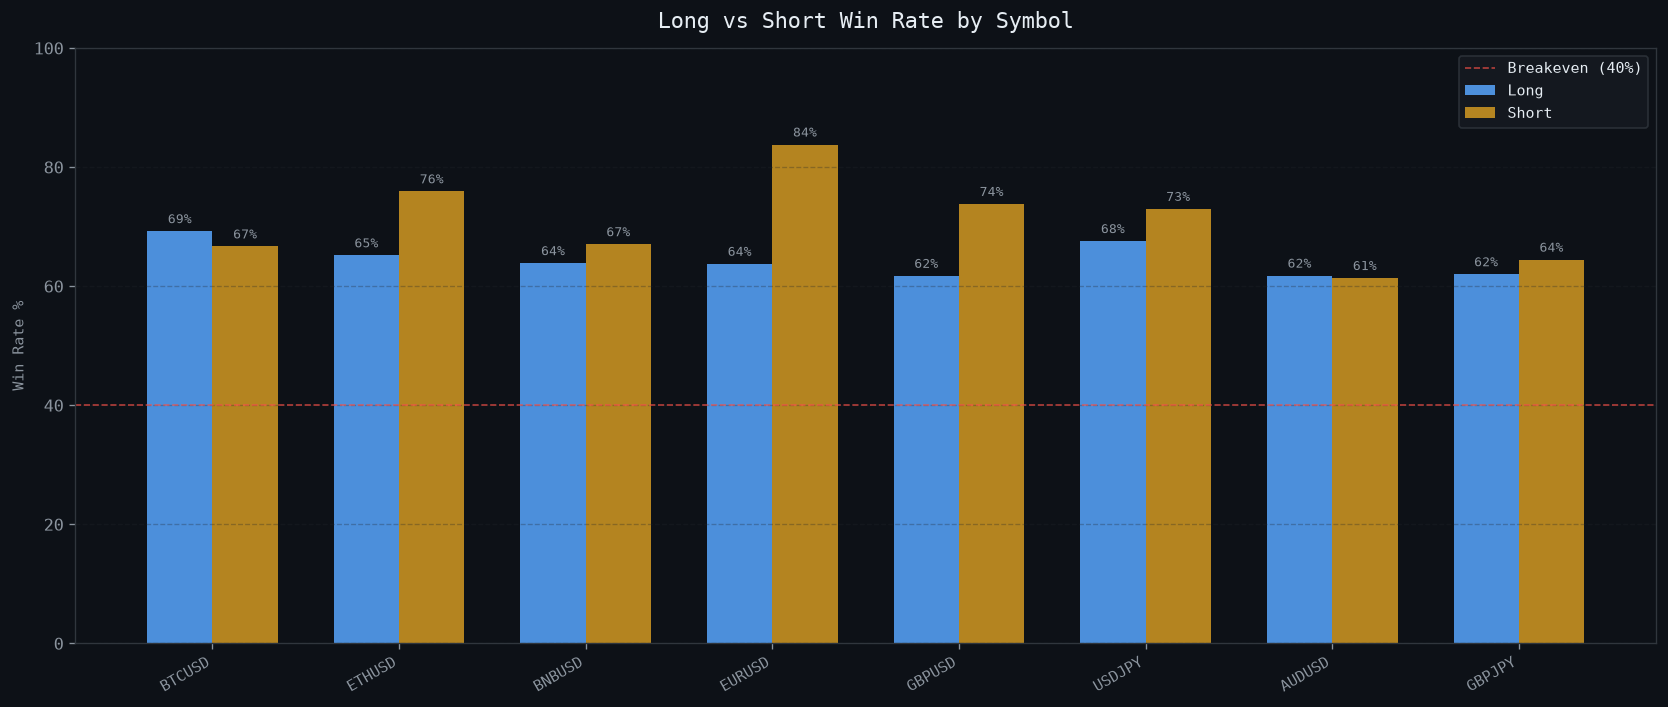

In [88]:
# ============================================================
# LONG VS SHORT WIN RATE BY SYMBOL
# ============================================================

long_wrs  = []
short_wrs = []

for symbol in SYMBOLS:
    df     = trades[symbol]
    longs  = df[df["direction"] == "long"]
    shorts = df[df["direction"] == "short"]
    long_wrs.append((longs["success"] == 1).mean() * 100)
    short_wrs.append((shorts["success"] == 1).mean() * 100)

x     = range(len(SYMBOLS))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

# grouped bars — long and short side by side
bars1 = ax.bar(
    [i - width/2 for i in x], long_wrs,
    width, label="Long", color=COLORS["blue"], alpha=0.85
)
bars2 = ax.bar(
    [i + width/2 for i in x], short_wrs,
    width, label="Short", color=COLORS["orange"], alpha=0.85
)

# breakeven reference line
ax.axhline(
    40, color=COLORS["red"], linewidth=1.0,
    linestyle="--", alpha=0.7, label="Breakeven (40%)"
)

# add percentage labels on top of each bar
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
        f"{bar.get_height():.0f}%",
        ha="center", va="bottom", fontsize=8, color=COLORS["muted"]
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
        f"{bar.get_height():.0f}%",
        ha="center", va="bottom", fontsize=8, color=COLORS["muted"]
    )

ax.set_xticks(x)
ax.set_xticklabels(SYMBOLS, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Win Rate %", fontsize=9, color=COLORS["muted"])
ax.set_title(
    "Long vs Short Win Rate by Symbol",
    color=COLORS["white"], fontsize=13, pad=12
)
ax.legend(fontsize=9)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("plots/long_short_winrate.png", dpi=150, bbox_inches="tight",
            facecolor=COLORS["bg"])
plt.show()

### Win / Loss Distribution

The chart below shows the total number of winning and losing trades per instrument, with the overall win rate displayed above each bar.
This gives a clear picture of how many trades each instrument generates and how consistently the edge holds across the portfolio.

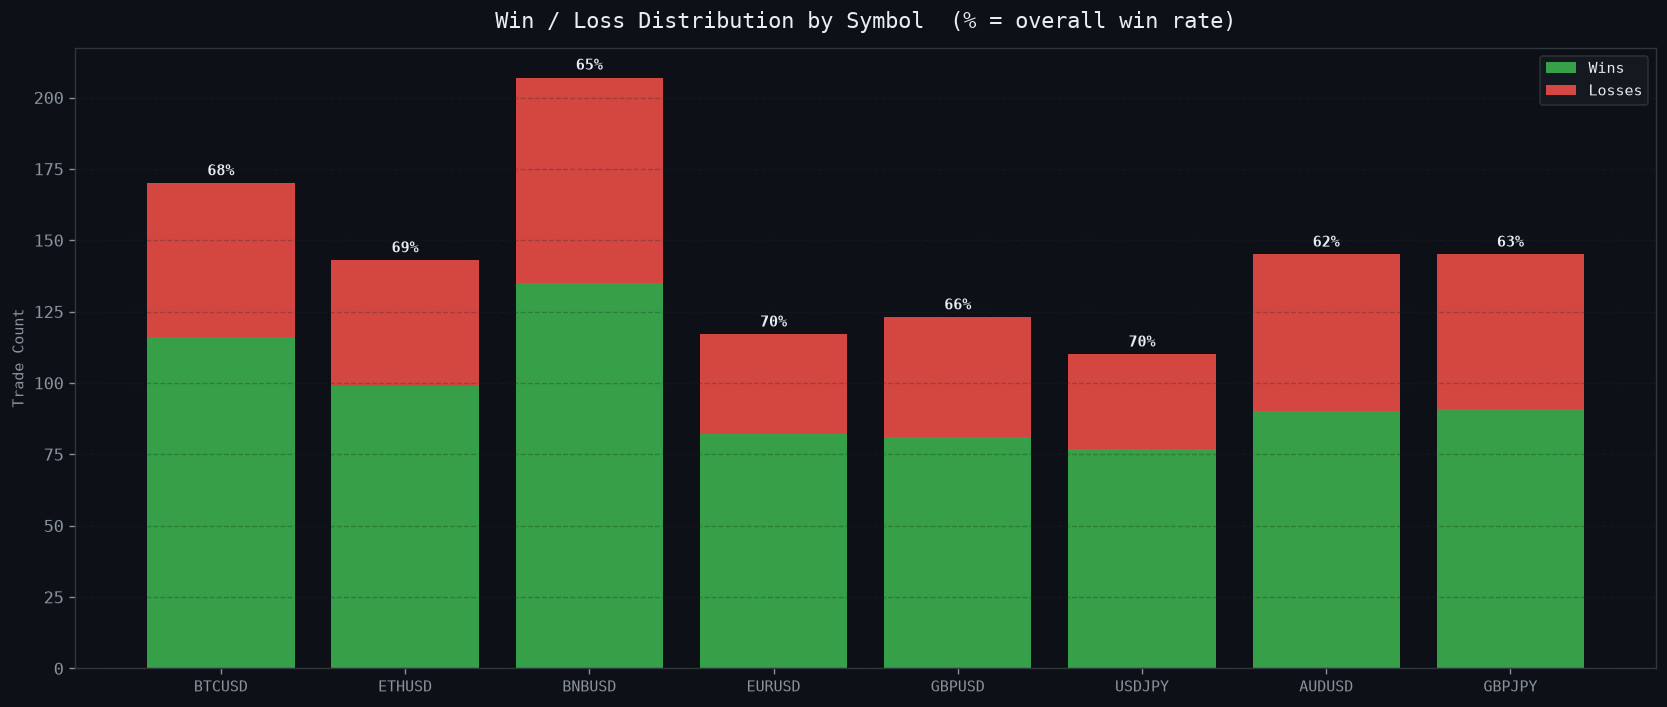

In [89]:
# ============================================================
# WIN / LOSS COUNT BY SYMBOL
# ============================================================

win_counts  = []
loss_counts = []

for symbol in SYMBOLS:
    df = trades[symbol]
    win_counts.append((df["success"] == 1).sum())
    loss_counts.append((df["success"] == 0).sum())

x = range(len(SYMBOLS))

fig, ax = plt.subplots(figsize=(14, 6))

# stacked bars — wins on bottom, losses stacked on top
ax.bar(x, win_counts,  label="Wins",   color=COLORS["green"], alpha=0.85)
ax.bar(x, loss_counts, label="Losses", color=COLORS["red"],
       alpha=0.85, bottom=win_counts)

# add win rate percentage above each bar
for i, (w, l) in enumerate(zip(win_counts, loss_counts)):
    total = w + l
    wr    = w / total * 100
    ax.text(
        i, total + 1.5,
        f"{wr:.0f}%",
        ha="center", va="bottom",
        fontsize=9, color=COLORS["white"], fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(SYMBOLS, fontsize=9)
ax.set_ylabel("Trade Count", fontsize=9, color=COLORS["muted"])
ax.set_title(
    "Win / Loss Distribution by Symbol  (% = overall win rate)",
    color=COLORS["white"], fontsize=13, pad=12
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("plots/win_loss_distribution.png", dpi=150, bbox_inches="tight",
            facecolor=COLORS["bg"])
plt.show()

## v. Trade Viewer

The interactive trade viewer below allows inspection of any individual trade 
from the dataset. Set the symbol and trade_num variables to view the 15-minute 
chart for that trade, showing:

- **Entry point**:- marked with a blue arrow
- **Stop loss**:- red dashed horizontal line  
- **Take profit target**:- green dashed horizontal line
- **Outcome**:- win or loss marked at the exit candle

This provides direct visual evidence that the reported results correspond to 
real price action — not just numbers in a table. Strategy indicators are 
intentionally omitted from this public view.

**How to use:**
```python
symbol = "BTCUSD"   # any of the 8 symbols
trade_num = 5          # any number from 0 to len(trades[symbol]) - 1
```

In [79]:
# ============================================================
# TRADE VIEWER
# ============================================================

import MetaTrader5 as mt5

# --- connect to MT5 to fetch candle data ---
mt5.initialize()


def fetch_candles_around_trade(symbol, entry_time, candles_before=50, candles_after=50):
    """
    Fetch 15-minute candles around a specific trade entry time.
    Requires MT5 to be running with the symbol available.
    """

    # strip timezone for MT5 compatibility
    if hasattr(entry_time, "tzinfo") and entry_time.tzinfo is not None:
        entry_time = entry_time.replace(tzinfo=None)

    # calculate the date range to fetch
    start = entry_time - pd.Timedelta(minutes=15 * candles_before)
    end   = entry_time + pd.Timedelta(minutes=15 * candles_after)

    # fetch from MT5
    rates = mt5.copy_rates_range(symbol, mt5.TIMEFRAME_M15, start, end)

    if rates is None or len(rates) == 0:
        print(f"No data returned for {symbol} around {entry_time}")
        return None

    df = pd.DataFrame(rates)
    df["time"] = pd.to_datetime(df["time"], unit="s")
    df = df[["time", "open", "high", "low", "close"]].set_index("time")

    return df


def view_trade(symbol, trade_num, candles_before=50, candles_after=30):
    """
    Plot the 15-minute candlestick chart for a specific trade.
    Shows entry, stop loss, take profit and exit markers.
    Strategy indicators are intentionally omitted.

    Parameters:
        symbol         : instrument name e.g. "BTCUSD"
        trade_num      : index of the trade in the trades[symbol] dataframe
        candles_before : candles to show before entry
        candles_after  : candles to show after entry
    """

    # --- validate inputs ---
    if symbol not in trades:
        print(f"Symbol {symbol} not found. Available: {list(trades.keys())}")
        return

    df_trades = trades[symbol]

    if trade_num < 0 or trade_num >= len(df_trades):
        print(f"Trade number must be between 0 and {len(df_trades) - 1}")
        return

    # --- get trade details ---
    trade      = df_trades.iloc[trade_num]
    entry_time = df_trades.index[trade_num]
    direction  = trade["direction"]
    entry      = trade["entry_price"]
    stop       = trade["stop"]
    target     = trade["target"]
    outcome    = "WIN" if trade["success"] == 1 else "LOSS"
    pnl_r      = trade["pnl_r"]
    year       = trade["year"]

    # --- fetch candles from MT5 ---
    df_chart = fetch_candles_around_trade(
        symbol, entry_time, candles_before, candles_after
    )

    if df_chart is None:
        return

    # --- find entry candle index ---
    entry_time_naive = entry_time
    if hasattr(entry_time, "tzinfo") and entry_time.tzinfo is not None:
        entry_time_naive = entry_time.replace(tzinfo=None)

    entry_idx = df_chart.index.get_indexer(
        [entry_time_naive], method="nearest"
    )[0]

    # --- scan forward to find exit candle ---
    exit_idx   = None
    exit_price = None

    for i in range(entry_idx + 1, len(df_chart)):
        candle = df_chart.iloc[i]
        if direction == "long":
            if candle["low"] <= stop:
                exit_idx   = i
                exit_price = stop
                break
            if candle["high"] >= target:
                exit_idx   = i
                exit_price = target
                break
        else:
            if candle["high"] >= stop:
                exit_idx   = i
                exit_price = stop
                break
            if candle["low"] <= target:
                exit_idx   = i
                exit_price = target
                break

    # --- build the chart ---
    fig, ax = plt.subplots(figsize=(18, 7))

    # plot each candle manually
    for i, (idx, row) in enumerate(df_chart.iterrows()):
        # green candle if close >= open, red otherwise
        color = COLORS["green"] if row["close"] >= row["open"] else COLORS["red"]

        # candle body
        ax.bar(
            i, abs(row["close"] - row["open"]),
            bottom=min(row["open"], row["close"]),
            width=0.6, color=color, alpha=0.9
        )

        # candle wick
        ax.plot(
            [i, i], [row["low"], row["high"]],
            color=color, linewidth=0.8, alpha=0.7
        )

    # --- stop loss line ---
    ax.axhline(
        stop, color=COLORS["red"], linewidth=1.0,
        linestyle="--", alpha=0.8,
        label=f"Stop: {stop:.5f}"
    )

    # --- take profit line ---
    ax.axhline(
        target, color=COLORS["green"], linewidth=1.0,
        linestyle="--", alpha=0.8,
        label=f"Target: {target:.5f}"
    )

    # --- entry marker ---
    marker = "^" if direction == "long" else "v"
    ax.scatter(
        entry_idx, entry,
        marker=marker, s=150,
        color=COLORS["blue"], zorder=5,
        label=f"Entry: {entry:.5f}"
    )

    # --- exit marker ---
    if exit_idx is not None:
        exit_color = COLORS["green"] if outcome == "WIN" else COLORS["red"]
        ax.scatter(
            exit_idx, exit_price,
            marker="x", s=150,
            color=exit_color, zorder=5, linewidths=2,
            label=f"Exit: {exit_price:.5f}"
        )

    # --- x axis labels every 10 candles ---
    tick_positions = list(range(0, len(df_chart), 10))
    tick_labels    = [
        df_chart.index[i].strftime("%d %b %H:%M")
        for i in tick_positions
        if i < len(df_chart)
    ]
    ax.set_xticks(tick_positions[:len(tick_labels)])
    ax.set_xticklabels(tick_labels, rotation=30, ha="right", fontsize=7)

    # --- title ---
    outcome_color = COLORS["green"] if outcome == "WIN" else COLORS["red"]
    ax.set_title(
        f"{symbol}  |  Trade #{trade_num}  |  {direction.upper()}  |  "
        f"{entry_time_naive.strftime('%Y-%m-%d %H:%M')}  |  "
        f"{outcome}  {pnl_r:+.1f}R",
        color=outcome_color, fontsize=13, pad=12
    )
    ax.set_ylabel("Price", fontsize=9, color=COLORS["muted"])
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    # --- print trade summary below chart ---
    print(f"\nTrade #{trade_num} — {symbol} {direction.upper()}")
    print(f"  Entry:   {entry:.5f}  at  {entry_time_naive}")
    print(f"  Stop:    {stop:.5f}")
    print(f"  Target:  {target:.5f}")
    print(f"  Outcome: {outcome}  ({pnl_r:+.1f}R)")
    print(f"  Year:    {year}")


print("Trade viewer ready")
print(f"Available symbols: {SYMBOLS}")
print(f"Usage: view_trade('BTCUSD', 5)")

Trade viewer ready
Available symbols: ['BTCUSD', 'ETHUSD', 'BNBUSD', 'EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'GBPJPY']
Usage: view_trade('BTCUSD', 5)


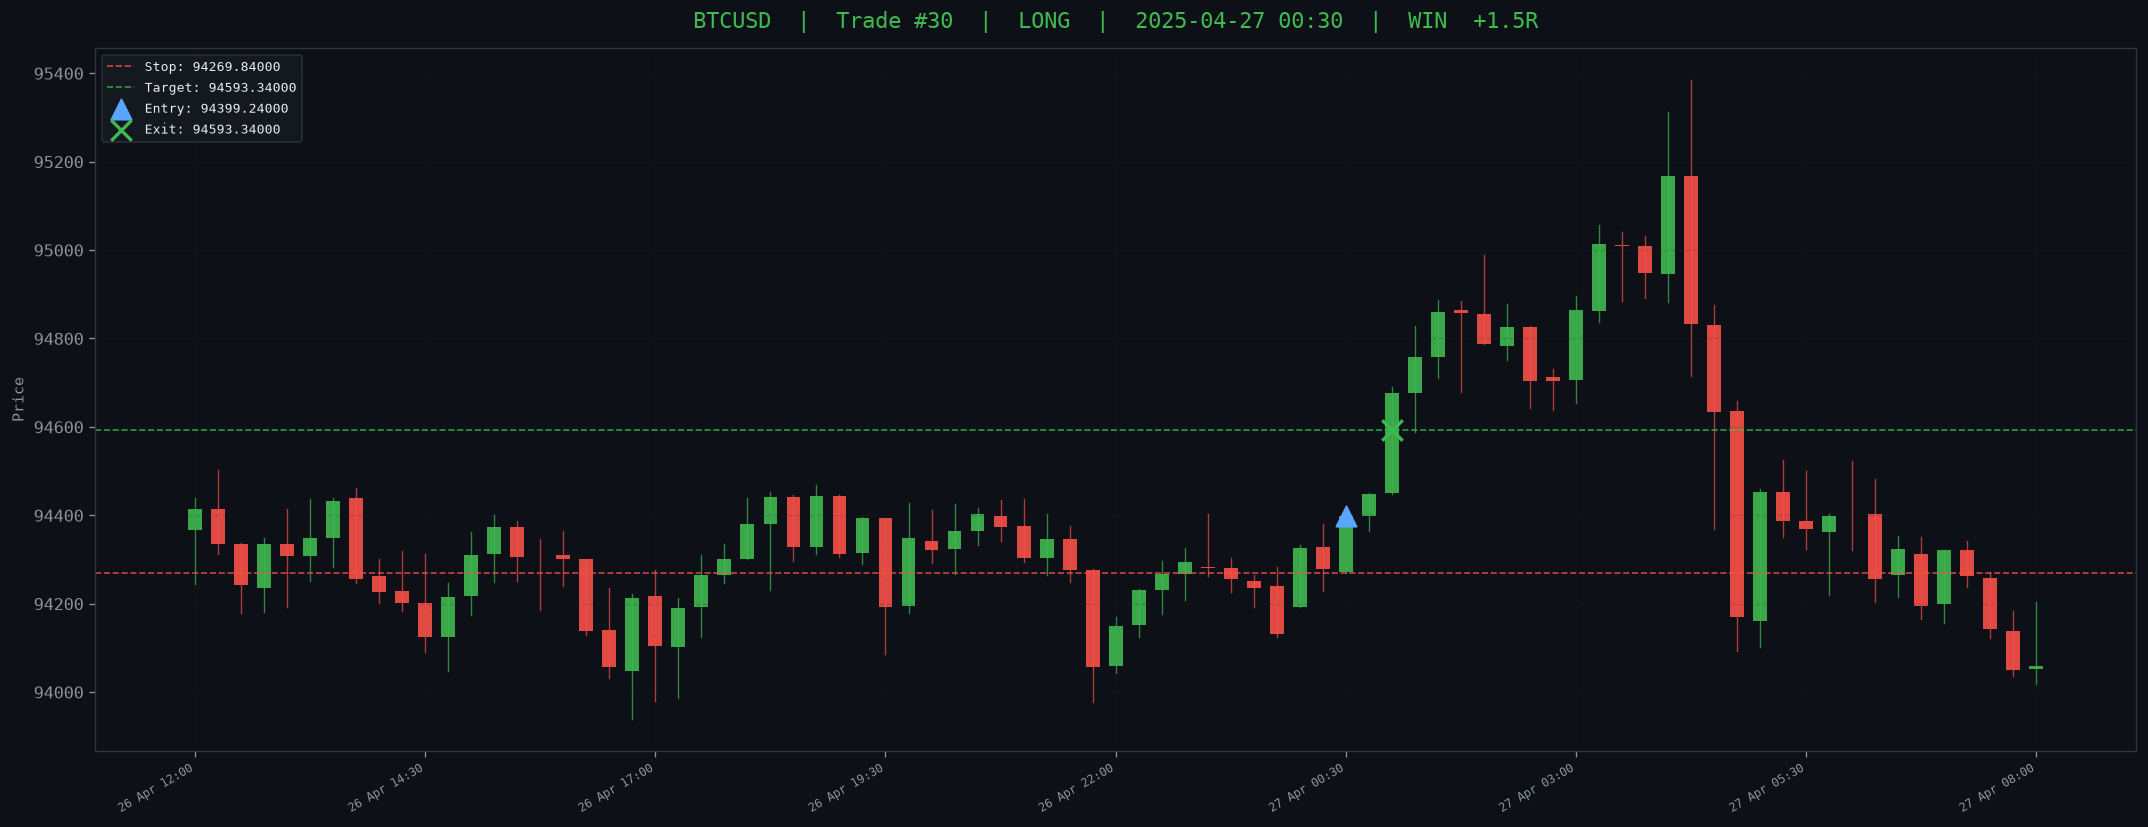


Trade #30 — BTCUSD LONG
  Entry:   94399.24000  at  2025-04-27 00:30:00
  Stop:    94269.84000
  Target:  94593.34000
  Outcome: WIN  (+1.5R)
  Year:    2025


In [84]:
# ============================================================
# VIEW A TRADE
# ============================================================

# change symbol and trade_num to inspect any trade
# trade_num ranges from 0 to len(trades[symbol]) - 1

symbol    = "BTCUSD"
trade_num = 30

view_trade(symbol, trade_num)

##  Current Status & Next Steps

### Where We Are

The results presented in this notebook represent the **backtesting phase** of the Trend Lens development cycle. The strategy has been validated across 8 instruments and 18 months of historical data using a systematic, reproducible pipeline.

The current phase is **walk-forward validation** — running the live automated execution system in parallel with the backtesting pipeline to confirm that:

1. The live bot detects the same signals the backtest identifies
2. Context classifications match between the live system and the research pipeline
3. Execution (entry price, stop placement, take profit) behaves as expected

This is a critical step that most public strategy presentations skip. A backtest that cannot be replicated in live execution is not a deployable strategy.

### Live System

The strategy is currently running on a **demo account** via an automated Python bot connected to MetaTrader 5. The bot:

- Monitors all 8 instruments simultaneously on the 15-minute timeframe
- Computes multi-timeframe regime context on every candle close
- Fires trades automatically when all entry conditions are met
- Places stop loss and take profit orders at execution

### What Comes Next

| Stage | Description | Status |
|-------|-------------|--------|
| Backtesting | Historical validation across 8 instruments | ✅ Complete |
| Walk-forward validation | Live bot vs backtest signal matching | 🔄 In progress |
| Live paper trading | 2-3 months of live demo results | 🔄 In progress |
| Live account deployment | Real capital, prop firm or personal account | ⏳ Pending validation |
| Strategy 2 | Second uncorrelated strategy added to portfolio | ⏳ Planned |

### A Note on Methodology

The strategy logic, context classification parameters and regime thresholds are intentionally omitted from this public document. What is presented here is the **evidence of the research process** — the hypothesis, the validation methodology, and the results — not the implementation details.

---

*For collaboration, questions or access to the full methodology — reach out via GitHub or LinkedIn.*

*Chinonso Anadumaka | Quantitative Trading Research | 2026*